<a href="https://colab.research.google.com/github/Theflawlessone/Face_Detection/blob/main/Notebooks/UTKFaces_preprocessing_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Imports
import os, tarfile, re, glob, random
from pathlib import Path
import pickle
import pandas as pd
import numpy as np
from PIL import Image
import torch
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from facenet_pytorch import MTCNN
from tqdm import tqdm
from PIL import Image

In [3]:
sns.set_theme(style="whitegrid", palette="pastel")

In [4]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

### Data extracting/loading:

In [38]:
BASE_DIR = Path.cwd().parent

RAW_DIR = BASE_DIR / "data" / "raw"
CROPPED_DIR = BASE_DIR / "data" / "cropped"

RAW_DIR.mkdir(parents=True, exist_ok=True)
CROPPED_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR =", BASE_DIR)
print("RAW_DIR =", RAW_DIR)
print("CROPPED_DIR =", CROPPED_DIR)

BASE_DIR = c:\Users\unent\Documents\GitHub\Face_Detection
RAW_DIR = c:\Users\unent\Documents\GitHub\Face_Detection\data\raw
CROPPED_DIR = c:\Users\unent\Documents\GitHub\Face_Detection\data\cropped


In [22]:
ARCHIVES = [
    RAW_DIR / "part1.tar.gz",
    RAW_DIR / "part2.tar.gz",
    RAW_DIR / "part3.tar.gz",
]

def safe_extract(tar_path: Path, extract_to: Path):
    """
    Safely extract a tar archive into `extract_to`
    """
    with tarfile.open(tar_path, "r:*") as tar:
        for member in tar.getmembers():
            member_path = (extract_to / member.name).resolve()
            if not str(member_path).startswith(str(extract_to.resolve())):
                raise Exception(f"Unsafe path in {tar_path}: {member.name}")
        tar.extractall(extract_to)
    print(f"Extracted {tar_path.name}")

# Idempotent extraction loop
for arc in ARCHIVES:
    flag = RAW_DIR / f".done_{arc.name}"
    if flag.exists():
        print(f"Already extracted: {arc.name}")
        continue
    if not arc.exists():
        print(f"Missing archive: {arc}")
        continue
    safe_extract(arc, RAW_DIR)
    flag.touch()
    open(flag, "w").close()

Extracted part1.tar.gz
Extracted part2.tar.gz
Extracted part3.tar.gz


In [ ]:
image_paths = sorted(RAW_DIR.rglob("*.jpg"))
print(f"Found {len(image_paths)} images in total.")

# Collect & Parse Metadata
def is_valid_image(path):
    try:
        img = Image.open(path)
        img.verify()
        return True
    except:
        return False

def parse_label(path):
    """
    Parse UTKFace filename: age_gender_race_*.jpg
    gender: 0 = male, 1 = female
    race: 0 = White, 1 = Black, 2 = Asian, 3 = Indian, 4 = Others
    """
    name = path.name
    match = re.match(r"(\d+)_(\d+)_(\d+)_", name)
    if not match:
        return None, None, None
    age = int(match.group(1))
    gender = int(match.group(2))
    race = int(match.group(3))
    return age, gender, race

records = []
for p in image_paths:
    if not is_valid_image(p):
        continue
    age, gender, race = parse_label(p)
    if age is None:
        continue
    rel_path = p.relative_to(BASE_DIR)
    records.append([str(rel_path), age, gender, race])

df_raw = pd.DataFrame(records, columns=["raw_path", "age", "gender", "race"])
print("After cleaning:", len(df_raw))
df_raw.head()

Found 24106 images in total.
After cleaning: 24102


,raw_path,age,gender,race
0,data\raw\part1\100_1_0_20170110183726390.jpg,100,1,0
1,data\raw\part1\100_1_2_20170105174847679.jpg,100,1,2
2,data\raw\part1\100_1_2_20170110182836729.jpg,100,1,2
3,data\raw\part1\101_1_2_20170105174739309.jpg,101,1,2
4,data\raw\part1\10_0_0_20161220222308131.jpg,10,0,0


In [40]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# MTCNN face detector
mtcnn = MTCNN(
    image_size=224,   # final face size
    margin=20,        # add a bit of context around face
    post_process=False,
    device=device
)

Using device: cpu


In [ ]:
def build_cropped_dataframe(
    df_raw,
    base_dir,
    cropped_dir,
    mtcnn
):
    """
    Build a dataframe pointing to cropped face images.
    """
    base_dir = Path(base_dir)
    cropped_dir = Path(cropped_dir)
    cropped_dir.mkdir(parents=True, exist_ok=True)

    records = []
    failed = []

    for _, row in tqdm(df_raw.iterrows(), total=len(df_raw), desc="Cropping"):
        raw_rel = Path(row["path"])
        raw_abs = base_dir / raw_rel

        filename = raw_abs.name
        cropped_abs = cropped_dir / filename

        # if cropped file already exists, reuse
        if cropped_abs.is_file():
            cropped_rel = cropped_abs.relative_to(base_dir)
            rec = row.to_dict()
            rec["path"] = str(cropped_rel)
            records.append(rec)
            continue

        # crop from raw image
        try:
            img = Image.open(raw_abs).convert("RGB")
            with torch.no_grad():
                face_tensor = mtcnn(img)
        except Exception:
            failed.append(str(raw_abs))
            continue

        if face_tensor is None:
            failed.append(str(raw_abs))
            continue

        # Convert tensor -> PIL
        face_tensor = face_tensor.clamp(0, 255)
        np_img = face_tensor.permute(1, 2, 0).cpu().numpy().astype("uint8")
        cropped_img = Image.fromarray(np_img)
        cropped_img.save(cropped_abs)

        # Add row
        rec = row.to_dict()
        rec["path"] = str(cropped_abs.relative_to(base_dir))
        records.append(rec)

    df_cropped = pd.DataFrame(records)
    print(f"\nTotal raw rows: {len(df_raw)}")
    print(f"Total cropped rows: {len(df_cropped)}")
    print(f"Failed: {len(failed)}")

    return df_cropped, failed

In [48]:
df_cropped, failed = build_cropped_dataframe(
    df_raw=df_raw,
    base_dir=BASE_DIR,
    cropped_dir=CROPPED_DIR,
    mtcnn=mtcnn
)

Cropping: 100%|██████████| 24102/24102 [00:06<00:00, 3858.16it/s]


Total raw rows: 24102
Total cropped rows: 24076
Failed: 26


In [50]:
df_cropped['path'].iloc[1]

'data\\cropped\\100_1_2_20170105174847679.jpg'

In [51]:
# Age Buckets
# 0–12: 0 (Child)
# 13–19: 1 (Teenager)
# 20–39: 2 (Young Adult)
# 40–59: 3 (Middle-Aged)
# 60+: 4 (Senior)

NUM_AGE_GROUPS = 5
NUM_GENDERS = 2
NUM_RACES = 5

def age_to_group(age):
    if age <= 12:
        return 0
    elif age <= 19:
        return 1
    elif age <= 39:
        return 2
    elif age <= 59:
        return 3
    else:
        return 4

df_cropped["age_group"] = df_cropped["age"].apply(age_to_group)

In [52]:
# Map readable gender, race, and age group strings
gender_map = {0: "Male", 1: "Female"}
race_map = {0: "White", 1: "Black", 2: "Asian", 3: "Indian", 4: "Other"}
age_group_map = {
    0: "Child (0–12)",
    1: "Teen (13–19)",
    2: "Young Adult (20–39)",
    3: "Middle-Aged (40–59)",
    4: "Senior (60+)"
}

df_cropped["gender_str"] = df_cropped["gender"].map(gender_map)
df_cropped["race_str"] = df_cropped["race"].map(race_map)
df_cropped["age_group_str"] = df_cropped["age_group"].map(age_group_map)

In [53]:
print("Gender distribution:")
print(df_cropped["gender_str"].value_counts())

print("\nRace distribution:")
print(df_cropped["race_str"].value_counts())

print("\nAge group distribution:")
print(df_cropped["age_group_str"].value_counts())

Gender distribution:
gender_str
Male      12566
Female    11510
Name: count, dtype: int64

Race distribution:
race_str
White     10212
Black      4556
Indian     4023
Asian      3576
Other      1709
Name: count, dtype: int64

Age group distribution:
age_group_str
Young Adult (20–39)    11905
Middle-Aged (40–59)     4555
Child (0–12)            3672
Senior (60+)            2745
Teen (13–19)            1199
Name: count, dtype: int64


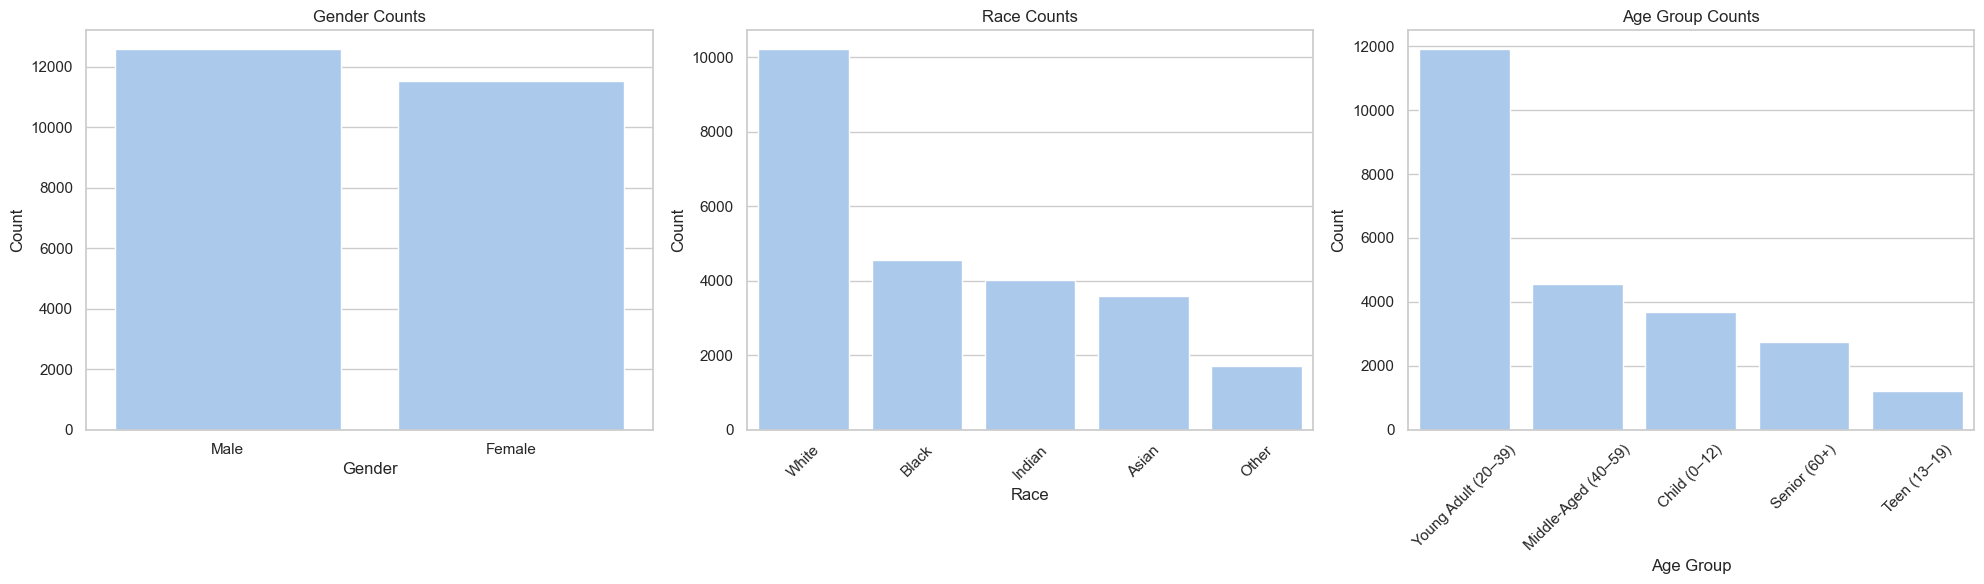

In [54]:
fig, axs = plt.subplots(1, 3, figsize=(20, 6))

sns.countplot(
    data=df_cropped,
    x="gender_str",
    order=df_cropped["gender_str"].value_counts().index,
    ax=axs[0]
)
axs[0].set_title("Gender Counts")
axs[0].set_xlabel("Gender")
axs[0].set_ylabel("Count")

sns.countplot(
    data=df_cropped,
    x="race_str",
    order=df_cropped["race_str"].value_counts().index,
    ax=axs[1]
)
axs[1].set_title("Race Counts")
axs[1].set_xlabel("Race")
axs[1].set_ylabel("Count")
axs[1].tick_params(axis='x', rotation=45)

sns.countplot(
    data=df_cropped,
    x="age_group_str",
    order=df_cropped["age_group_str"].value_counts().index,
    ax=axs[2]
)
axs[2].set_title("Age Group Counts")
axs[2].set_xlabel("Age Group")
axs[2].set_ylabel("Count")
axs[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [57]:
# Stratify by age_group for more balanced splits
train_df, temp_df = train_test_split(
    df_cropped,
    test_size=0.3,
    random_state=SEED,
    stratify=df_cropped["age_group"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_df["age_group"]
)

print(len(train_df), len(val_df), len(test_df))

16853 3611 3612


In [58]:
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"\n{name.upper()} distribution:")
    print("Age groups:\n", d["age_group_str"].value_counts())
    print("Gender:\n", d["gender_str"].value_counts())
    print("Race:\n", d["race_str"].value_counts())


TRAIN distribution:
Age groups:
 age_group_str
Young Adult (20–39)    8333
Middle-Aged (40–59)    3189
Child (0–12)           2570
Senior (60+)           1922
Teen (13–19)            839
Name: count, dtype: int64
Gender:
 gender_str
Male      8816
Female    8037
Name: count, dtype: int64
Race:
 race_str
White     7167
Black     3132
Indian    2832
Asian     2526
Other     1196
Name: count, dtype: int64

VAL distribution:
Age groups:
 age_group_str
Young Adult (20–39)    1786
Middle-Aged (40–59)     683
Child (0–12)            551
Senior (60+)            411
Teen (13–19)            180
Name: count, dtype: int64
Gender:
 gender_str
Male      1863
Female    1748
Name: count, dtype: int64
Race:
 race_str
White     1512
Black      725
Indian     598
Asian      531
Other      245
Name: count, dtype: int64

TEST distribution:
Age groups:
 age_group_str
Young Adult (20–39)    1786
Middle-Aged (40–59)     683
Child (0–12)            551
Senior (60+)            412
Teen (13–19)            180
N

### Save splits:
---

In [59]:
PICKLE_DIR = BASE_DIR / "pickle_files"
PICKLE_DIR.mkdir(parents=True, exist_ok=True)

with open(os.path.join(PICKLE_DIR, "df_cropped.pkl"), "wb") as f:
    pickle.dump(df_cropped, f)

with open(os.path.join(PICKLE_DIR, "train_df.pkl"), "wb") as f:
    pickle.dump(train_df, f)
with open(os.path.join(PICKLE_DIR, "val_df.pkl"), "wb") as f:
    pickle.dump(val_df, f)
with open(os.path.join(PICKLE_DIR, "test_df.pkl"), "wb") as f:
    pickle.dump(test_df, f)

### Load pickles:

In [60]:
# START HERE
def load_pickle_from_repo(filename, base_dir=None):
    """
    Load a pickle file stored locally inside the repo's /pickle_files folder.
    """
    if base_dir is None:
        base_dir = Path.cwd().parent

    pickle_path = base_dir / "pickle_files" / filename

    if not pickle_path.exists():
        raise FileNotFoundError(f"Pickle not found: {pickle_path}")

    with open(pickle_path, "rb") as f:
        return pickle.load(f)

In [65]:
train_df = load_pickle_from_repo("train_df.pkl")
val_df   = load_pickle_from_repo("val_df.pkl")
test_df  = load_pickle_from_repo("test_df.pkl")
df_cropped = load_pickle_from_repo("df_cropped.pkl")

In [62]:
train_df["path"].iloc[1]

'data\\cropped\\16_1_2_20170109214552372.jpg'

In [66]:
train_df["filename"] = train_df["path"].apply(lambda p: Path(p).name)
val_df["filename"]   = val_df["path"].apply(lambda p: Path(p).name)
test_df["filename"]  = test_df["path"].apply(lambda p: Path(p).name)
df_cropped["filename"] = df_cropped["path"].apply(lambda p: Path(p).name)

In [67]:
train_df['filename']

8703      6_1_1_20170103223434927.jpg
875      16_1_2_20170109214552372.jpg
19128    49_0_3_20170117130537950.jpg
6110     42_1_3_20170109141104388.jpg
18595    42_1_2_20170116162349143.jpg
                     ...             
2332      1_1_3_20161219224822176.jpg
4175      2_0_2_20161219203844252.jpg
3825     28_1_2_20170104021815094.jpg
19240    50_0_1_20170117175738076.jpg
21721    27_0_2_20170119193329569.jpg
Name: filename, Length: 16853, dtype: object

# Checking Dataset columns and ensuring we can access the images

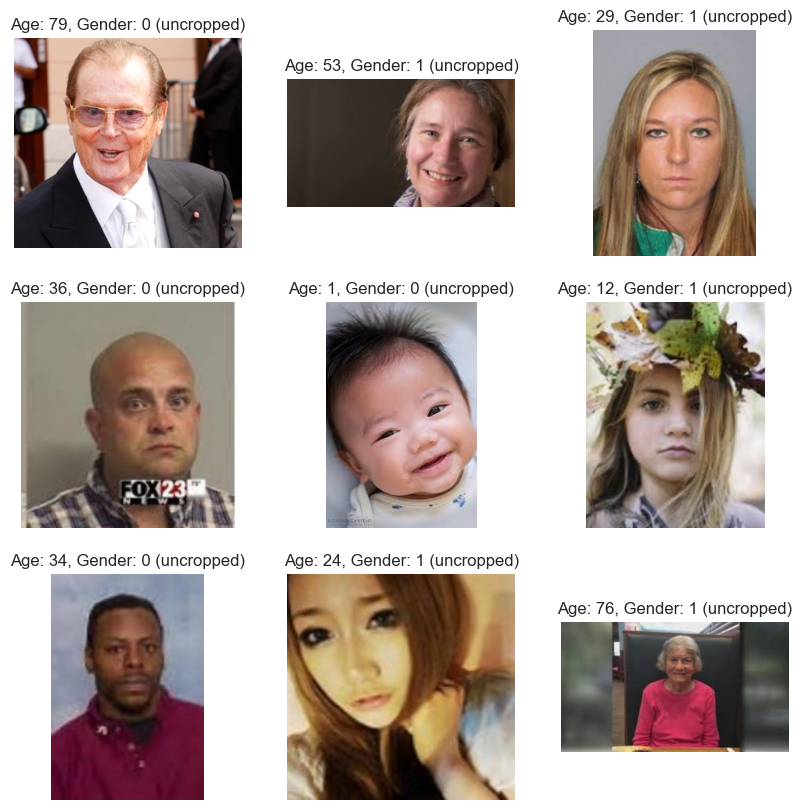

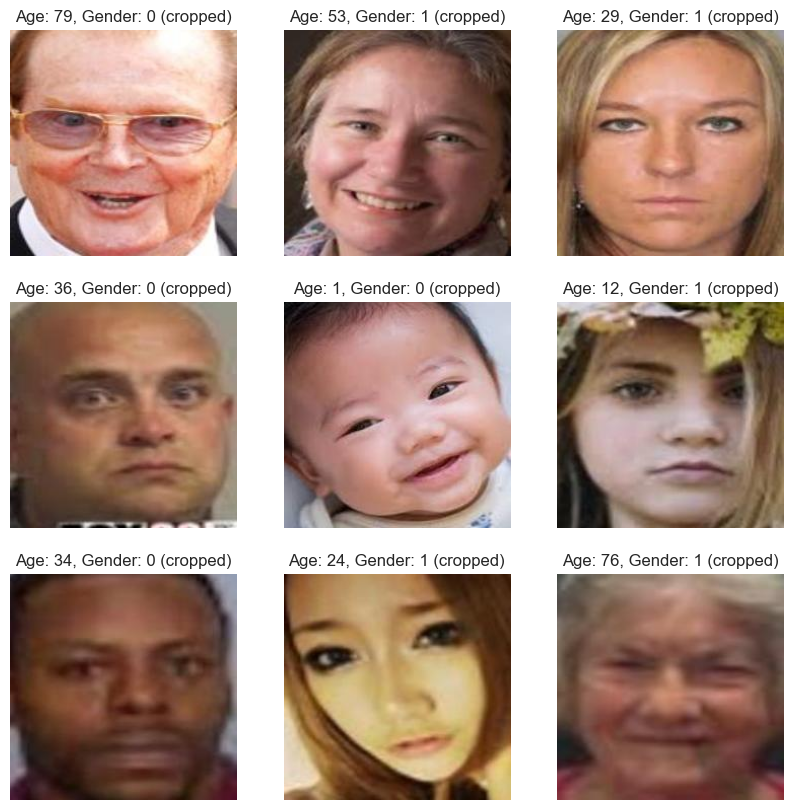

In [ ]:
sample = df_cropped.sample(9, random_state=SEED)

plt.figure(figsize=(10, 10))
for i, row in enumerate(sample.itertuples(), 1):
    full_path = BASE_DIR / row.raw_path  # raw image
    img = Image.open(full_path)
    plt.subplot(3, 3, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Age: {row.age}, Gender: {row.gender} (uncropped)")
plt.show()

plt.figure(figsize=(10, 10))
for i, row in enumerate(sample.itertuples(), 1):
    full_path = BASE_DIR / row.path  # cropped image
    img = Image.open(full_path)
    plt.subplot(3, 3, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Age: {row.age}, Gender: {row.gender} (cropped)")
plt.show()

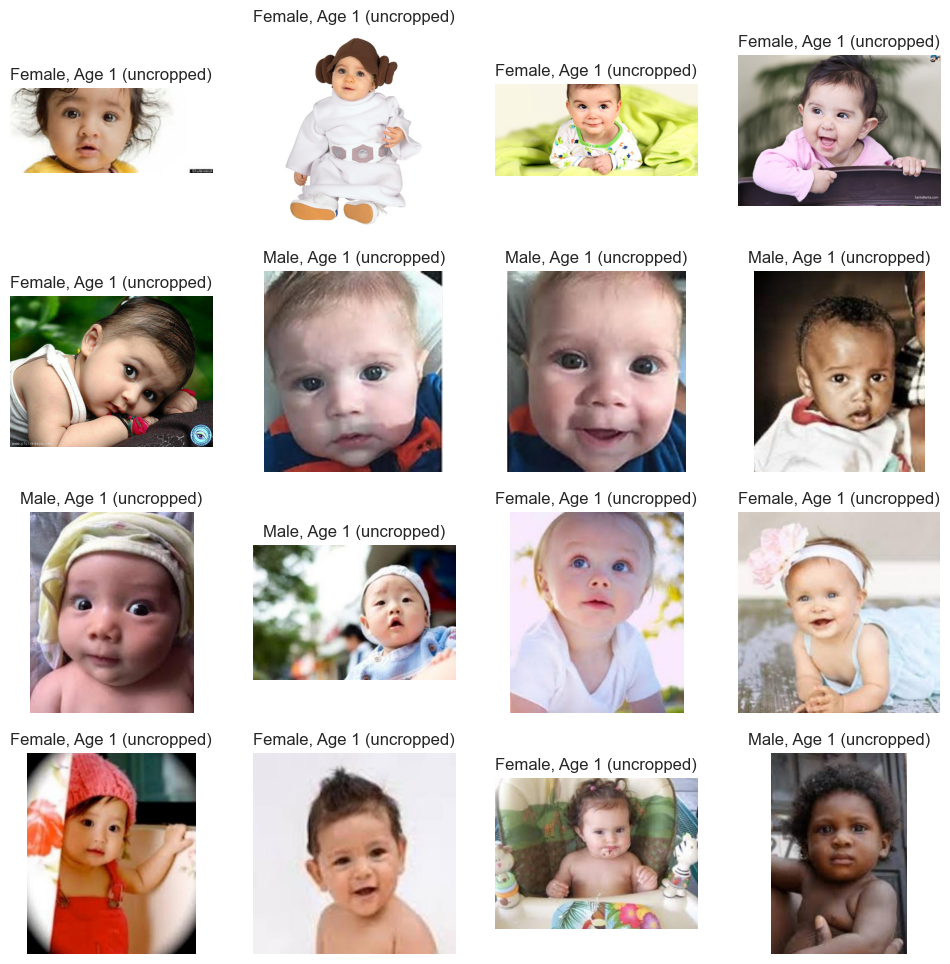

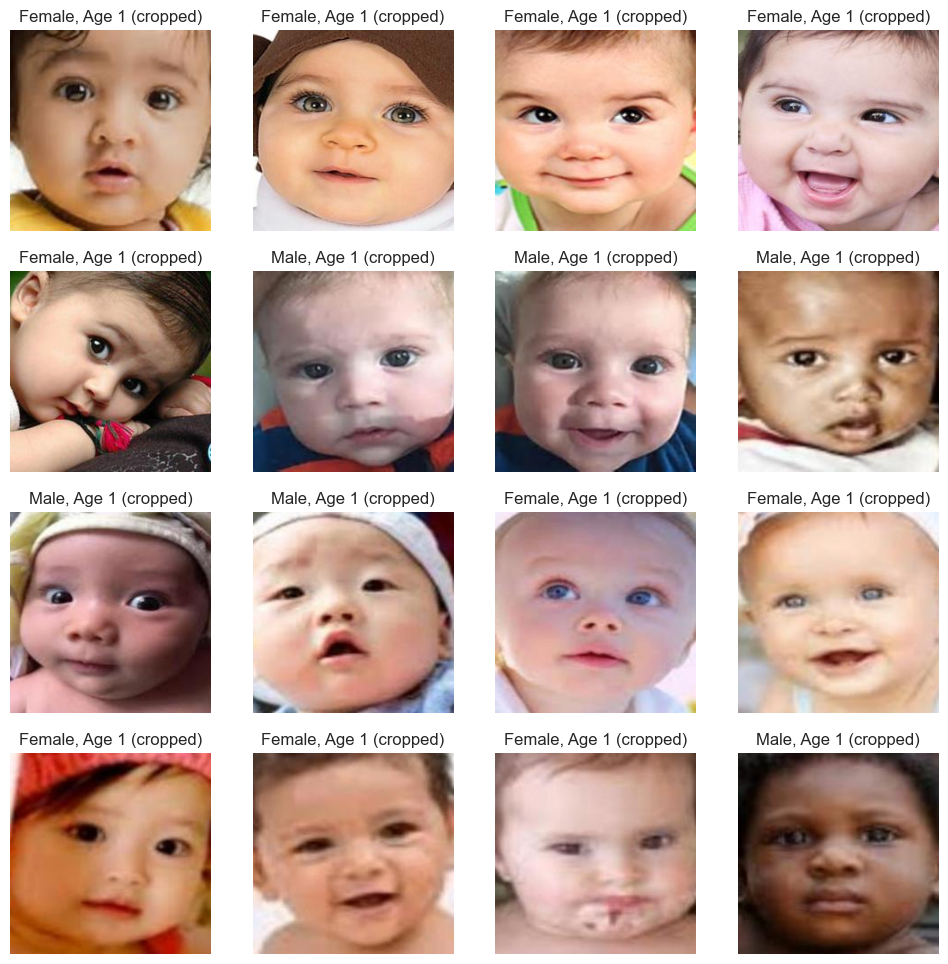

In [80]:
age1_df = df_cropped[df_cropped["age"] == 1]

plt.figure(figsize=(12, 12))

for i, row in enumerate(age1_df.tail(16).itertuples(), 1):  # show last 16
    full_path = BASE_DIR / row.raw_path
    img = Image.open(full_path)
    plt.subplot(4, 4, i)
    plt.imshow(img)
    plt.axis("off")
    gender_label = "Male" if row.gender == 0 else "Female"
    plt.title(f"{gender_label}, Age 1 (uncropped)")

plt.show()

plt.figure(figsize=(12, 12))

for i, row in enumerate(age1_df.tail(16).itertuples(), 1):  # show last 16
    full_path = BASE_DIR / row.path
    img = Image.open(full_path)
    plt.subplot(4, 4, i)
    plt.imshow(img)
    plt.axis("off")
    gender_label = "Male" if row.gender == 0 else "Female"
    plt.title(f"{gender_label}, Age 1 (cropped)")

plt.show()

# Summary Statistics

In [81]:
print(df_cropped.describe())

                age        gender          race     age_group
count  24076.000000  24076.000000  24076.000000  24076.000000
mean      33.059271      0.478069      1.271515      2.062386
std       20.124446      0.499529      1.343978      1.140736
min        1.000000      0.000000      0.000000      0.000000
25%       23.000000      0.000000      0.000000      2.000000
50%       29.000000      0.000000      1.000000      2.000000
75%       45.000000      1.000000      2.000000      3.000000
max      116.000000      1.000000      4.000000      4.000000


In [82]:
print("Gender distribution:")
print("0 is male and 1 is female")
print(df_cropped["gender"].value_counts())

Gender distribution:
0 is male and 1 is female
gender
0    12566
1    11510
Name: count, dtype: int64


In [83]:
print("Male %:", round(df_cropped[df_cropped.gender==0].shape[0] / len(df_cropped) * 100, 2))
print("Female %:", round(df_cropped[df_cropped.gender==1].shape[0] / len(df_cropped) * 100, 2))

Male %: 52.19
Female %: 47.81


In [84]:
print("Age distribution:")
print(df_cropped["age"].value_counts())

Age distribution:
age
26     2204
1      1269
28      921
35      879
24      861
       ... 
115       3
101       2
91        2
103       1
111       1
Name: count, Length: 104, dtype: int64


In [85]:
print("AGE 26 perentage:", round(df_cropped[df_cropped.age==26].shape[0] / len(df_cropped) * 100, 2))
print("AGE 1 perentage:", round(df_cropped[df_cropped.age==1].shape[0] / len(df_cropped) * 100, 2))
print("AGE 28 perentage:", round(df_cropped[df_cropped.age==28].shape[0] / len(df_cropped) * 100, 2))

AGE 26 perentage: 9.15
AGE 1 perentage: 5.27
AGE 28 perentage: 3.83


In [86]:
df_cropped[df_cropped["age"] == 1]["gender"].value_counts()

gender
0    716
1    553
Name: count, dtype: int64

# Graphs showing skewness/ unbalance

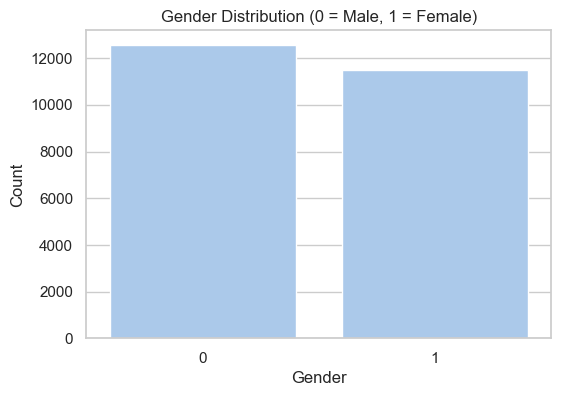

In [87]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_cropped, x="gender")
plt.title("Gender Distribution (0 = Male, 1 = Female)")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

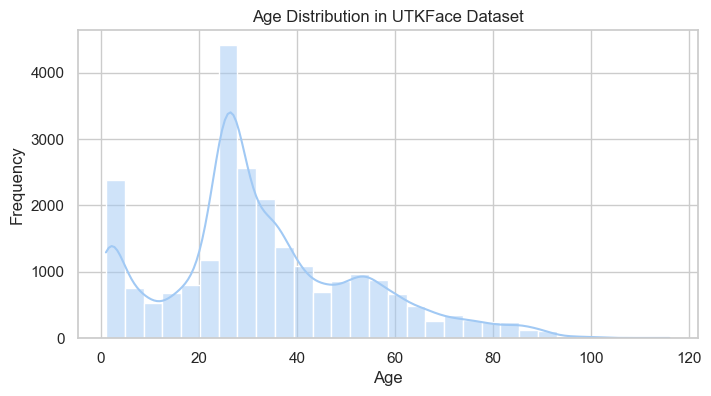

In [88]:
plt.figure(figsize=(8,4))
sns.histplot(df_cropped["age"], bins=30, kde=True)
plt.title("Age Distribution in UTKFace Dataset")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

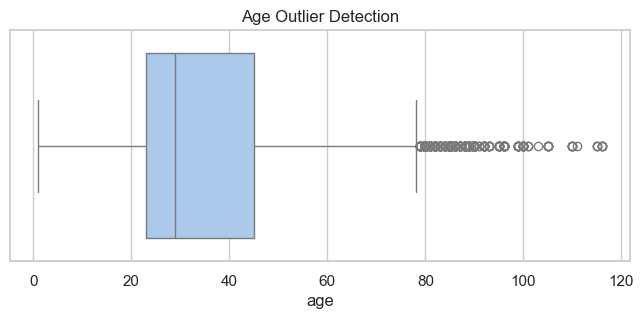

In [89]:
plt.figure(figsize=(8,3))
sns.boxplot(x=df_cropped["age"])
plt.title("Age Outlier Detection")
plt.show()

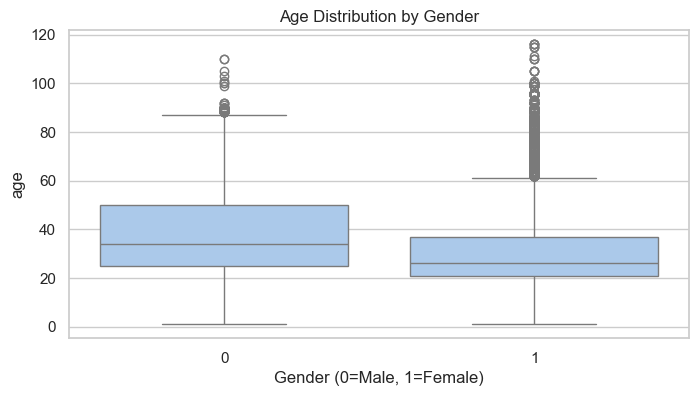

In [90]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df_cropped, x="gender", y="age")
plt.title("Age Distribution by Gender")
plt.xlabel("Gender (0=Male, 1=Female)")
plt.show()

In [91]:
if "raw_path" in df_cropped.columns:
    df_cropped = df_cropped.drop(columns=["raw_path"])

metadata_path = BASE_DIR / "data" / "metadata.csv"
df_cropped.to_csv(metadata_path, index=False)
print("Saved metadata to:", metadata_path)

Saved metadata to: c:\Users\unent\Documents\GitHub\Face_Detection\data\metadata.csv
